# 基于水果数据集的 PCA 特征降维与 ResNet 分类

本实验通过以下步骤完成水果图像的特征降维与分类：
1. 使用预训练的 ResNet-50 提取水果图像的高维特征
2. 应用 PCA 算法将高维特征降至低维空间
3. 对比原始特征与降维特征的分类性能
4. 使用 PCA 进行可视化分析

---

## 1. PCA 降维基础知识

### 1.1 什么是主成分分析 (PCA)？

主成分分析是一种无监督的降维技术，用于提取数据中最主要的信息。

**核心原理：**
- 找到数据方差最大的方向（主成分）
- 将高维数据投影到这些主成分上
- 减少数据维度同时保留大部分信息

**数学步骤：**
1. 数据标准化：$X' = \\frac{X - \\mu}{\\sigma}$
2. 计算协方差矩阵：$\\Sigma = \\frac{1}{n} X'^T X'$
3. 特征值分解：求出特征值 $\\lambda_1 \\geq \\lambda_2 \\geq ... \\geq \\lambda_n$
4. 选择前 k 个特征向量组成投影矩阵 $W$
5. 降维变换：$Y = X' \\cdot W$

**解释方差比例：**
$$\\text{Explained Ratio} = \\frac{\\lambda_i}{\\sum_{j=1}^{n} \\lambda_j}$$

### 1.2 PCA 的优势

- 减少计算复杂度
- 消除特征之间的相关性
- 便于数据可视化
- 减少过拟合风险

### 1.3 为什么要进行 PCA 可视化？

PCA 可视化是在特征降维后进行的高级分析技术，具有重要的机器学习价值：

**1. 诊断特征空间质量**
- 检查特征是否线性可分
- 评估类别之间的分离程度
- 发现是否存在异常值或离群点
- 验证降维是否保留了判别信息

**2. 理解模型的决策边界**
- 通过 2D/3D 投影观察模型在特征空间中的工作方式
- 发现某些类别可能被错误分类的原因
- 识别需要更复杂模型或特征工程的区域

**3. 特征工程改进**
- 评估当前特征集的质量
- 识别冗余或低质量的特征
- 指导后续的特征选择或构造
- 判断是否需要非线性降维（核 PCA、自编码器等）

**4. 模型可解释性**
- 提供模型可视化展示
- 帮助业务团队理解 AI 决策
- 发现潜在的数据偏差或标注错误

**5. 计算效率分析**
- 量化维度约简的收益
- 评估丢失的信息量
- 为模型部署决策提供数据支撑

**进阶技巧：**
- **主成分解释**：通过特征贡献度分析哪些原始特征最重要
- **增量 PCA**：处理超大数据集的流式降维
- **概率 PCA**：为模型提供概率解释
- **核 PCA**：处理非线性特征结构

## 2. 数据集介绍

### 2.1 CIFAR-10 数据集

使用的是公开的 CIFAR-10 数据集：
- **来源**：加拿大高级研究所 (CIFAR)
- **规模**：共 60,000 张图像（训练集 50,000 张，测试集 10,000 张）
- **类别**：10 种物体类别（飞机、汽车、鸟类、猫、鹿、狗、青蛙、马、船、卡车）
- **图像大小**：32×32 像素，RGB 格式，彩色图像
- **组织结构**：训练集和测试集分别存储

### 2.2 数据集特点

- **自动下载**：首次运行时自动从官方源下载（约 170MB）
- **标准化处理**：所有图像已标准化预处理
- **广泛应用**：被广泛用于深度学习研究和基准测试
- **适用场景**：特征提取、降维、分类等机器学习任务

## 3. 导入必要的库

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import urllib.request
import zipfile
import warnings
from tqdm import tqdm

# 深度学习库
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# 机器学习库
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

# 配置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print('✓ 所有库导入成功！')

✓ 所有库导入成功！


## 4. 下载和加载数据集

In [3]:
# 下载 CIFAR-10 数据集（仅 170MB）
import torchvision.datasets as datasets
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np

print('正在下载 CIFAR-10 数据集...')
print('（仅需 1-3 分钟，170MB）')

# 下载训练集和测试集
train_data = datasets.CIFAR10(root='data', train=True, download=True, transform=None)
test_data = datasets.CIFAR10(root='data', train=False, download=True, transform=None)

print(f'\n✓ CIFAR-10 下载完成!')
print(f'  训练集: {len(train_data)} 张图像')
print(f'  测试集: {len(test_data)} 张图像')
print(f'  类别: {train_data.classes}')

# 创建数据集包装类
class CIFAR10Dataset(Dataset):
    def __init__(self, dataset, indices=None, transform=None):
        self.dataset = dataset
        self.transform = transform
        self.indices = indices if indices is not None else range(len(dataset))
        self.classes = dataset.classes
        
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.dataset[real_idx]
        
        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)
            img = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                      std=[0.229, 0.224, 0.225])(img)
        return img, label

# 定义图像变换
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

# 使用前 5000 张训练图像（加速演示）
train_indices = np.random.choice(len(train_data), size=5000, replace=False)
train_dataset = CIFAR10Dataset(train_data, indices=train_indices, transform=transform)

print(f'\n  使用前 5000 张图像进行演示')
print(f'  🎓 学生提示: 修改上面的 5000 可调整数据量')

正在下载 CIFAR-10 数据集...
（仅需 1-3 分钟，170MB）

✓ CIFAR-10 下载完成!
  训练集: 50000 张图像
  测试集: 10000 张图像
  类别: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

  使用前 5000 张图像进行演示
  🎓 学生提示: 修改上面的 5000 可调整数据量


In [4]:
print('✓ CIFAR-10 数据集准备完成！')
print(f'  样本数: {len(train_dataset)}')
print(f'  类别数: {len(train_dataset.classes)}')
print(f'  类别列表: {train_dataset.classes}')

✓ CIFAR-10 数据集准备完成！
  样本数: 5000
  类别数: 10
  类别列表: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 5. 数据预处理

In [5]:
print('✓ 数据集已加载完毕！')
print(f'  总类别数: {len(train_dataset.classes)}')
print(f'  总图像数: {len(train_dataset)}')

✓ 数据集已加载完毕！
  总类别数: 10
  总图像数: 5000


## 6. ResNet-50 特征提取

In [7]:
# 导入所需库
import torch
import torch.nn as nn
import torchvision.models as models

# 检查设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

# 加载预训练 ResNet-50
model = models.resnet50(pretrained=True)
model.eval()
model = model.to(device)

# 定义特征提取器（移除最后的分类层）
class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.features = nn.Sequential(*list(model.children())[:-1])
    
    def forward(self, x):
        return self.features(x).view(x.size(0), -1)

extractor = FeatureExtractor(model).to(device)

print('✓ ResNet-50 模型加载成功！')
print('  特征维度: 2048')

使用设备: cpu


d:\Anaconda\envs\iris_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Anaconda\envs\iris_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\32077/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:13<00:00, 7.46MB/s]

✓ ResNet-50 模型加载成功！
  特征维度: 2048


In [8]:
# 提取特征
print('\n正在提取特征（可能需要 5-10 分钟）...')

all_features = []
all_labels = []

data_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=0)

with torch.no_grad():
    for idx, (images, labels) in enumerate(data_loader):
        if idx % 20 == 0:
            print(f'  处理批次 {idx+1}/{len(data_loader)}')
        
        images = images.to(device)
        features = extractor(images).cpu().numpy()
        all_features.append(features)
        all_labels.extend(labels.numpy())

all_features = np.concatenate(all_features, axis=0)
all_labels = np.array(all_labels)

print(f'\n✓ 特征提取完成！')
print(f'  特征形状: {all_features.shape}')
print(f'  标签形状: {all_labels.shape}')


正在提取特征（可能需要 5-10 分钟）...
  处理批次 1/157
  处理批次 21/157
  处理批次 41/157
  处理批次 61/157
  处理批次 81/157
  处理批次 101/157
  处理批次 121/157
  处理批次 141/157

✓ 特征提取完成！
  特征形状: (5000, 2048)
  标签形状: (5000,)


## 7. PCA 降维

In [10]:
# 导入所需库
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 特征标准化
scaler = StandardScaler()
features_scaled = scaler.fit_transform(all_features)

print('正在计算 PCA...')

# 先计算全部主成分以确定最优维度
pca_full = PCA()
pca_full.fit(features_scaled)

# 确定保留 95% 方差所需的主成分数
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumsum >= 0.95) + 1

print(f'✓ PCA 计算完成！')
print(f'  为保留 95% 方差，需要 {n_components} 个主成分')
print(f'  降维比例: 2048 → {n_components} ({n_components/2048*100:.1f}%)')

# 应用降维
pca = PCA(n_components=n_components)
features_pca = pca.fit_transform(features_scaled)

print(f'\n✓ 降维完成！')
print(f'  降维后特征: {features_pca.shape}')
print(f'  解释方差比: {pca.explained_variance_ratio_.sum():.4f}')

正在计算 PCA...
✓ PCA 计算完成！
  为保留 95% 方差，需要 508 个主成分
  降维比例: 2048 → 508 (24.8%)

✓ 降维完成！
  降维后特征: (5000, 508)
  解释方差比: 0.9494


## 8. 降维结果可视化

In [11]:
# 分析 PCA 投影的特征分离性\nprint('生成 PCA 2D 投影用于特征空间分析...')\npca_2d = PCA(n_components=2)\nfeatures_2d = pca_2d.fit_transform(features_scaled)\n\nprint(f'\\n✓ PCA 2D 投影完成！')\nprint(f'  第1主成分解释方差: {pca_2d.explained_variance_ratio_[0]:.4f} ({pca_2d.explained_variance_ratio_[0]:.2%})')\nprint(f'  第2主成分解释方差: {pca_2d.explained_variance_ratio_[1]:.4f} ({pca_2d.explained_variance_ratio_[1]:.2%})')\nprint(f'  两个主成分共解释方差: {pca_2d.explained_variance_ratio_.sum():.2%}')\n\n# 随机选择样本用于绘图（避免过拥挤）\nsample_indices = np.random.choice(len(features_2d), size=min(2000, len(features_2d)), replace=False)\nfeatures_2d_sample = features_2d[sample_indices]\nlabels_sample = all_labels[sample_indices]\n\nfig, ax = plt.subplots(figsize=(13, 10))\n\nscatter = ax.scatter(features_2d_sample[:, 0], \n                      features_2d_sample[:, 1],\n                      c=labels_sample, \n                      cmap='tab20', \n                      alpha=0.65, \n                      s=40,\n                      edgecolors='none')\n\nax.set_xlabel(f'PC1: {pca_2d.explained_variance_ratio_[0]:.2%} 方差', fontsize=13, fontweight='bold')\nax.set_ylabel(f'PC2: {pca_2d.explained_variance_ratio_[1]:.2%} 方差', fontsize=13, fontweight='bold')\nax.set_title('PCA 特征空间投影 - 水果类别分布可视化', fontsize=15, fontweight='bold', pad=20)\n\ncbar = plt.colorbar(scatter, ax=ax, label='水果类别编号')\nax.grid(True, alpha=0.2, linestyle='--')\n\nplt.tight_layout()\nplt.show()\n\n# 诊断分析\nprint('\\n特征空间质量诊断分析:')\nprint(f'  总样本数: {len(features_2d)}')\nprint(f'  可视化样本: {len(sample_indices)}')\nprint(f'  类别总数: {len(train_dataset.classes)}')\nprint(f'  特征维度: {features_scaled.shape[1]}')\nprint(f'  投影后维度: 2')\n\n# 主成分贡献分析\nprint('\\n主成分贡献度分析:')\nfor i, pc_var in enumerate(pca_2d.explained_variance_ratio_[:2]):\n    print(f'  PC{i+1}: {pc_var*100:.2f}%')"

## 9. PCA 2D 投影可视化

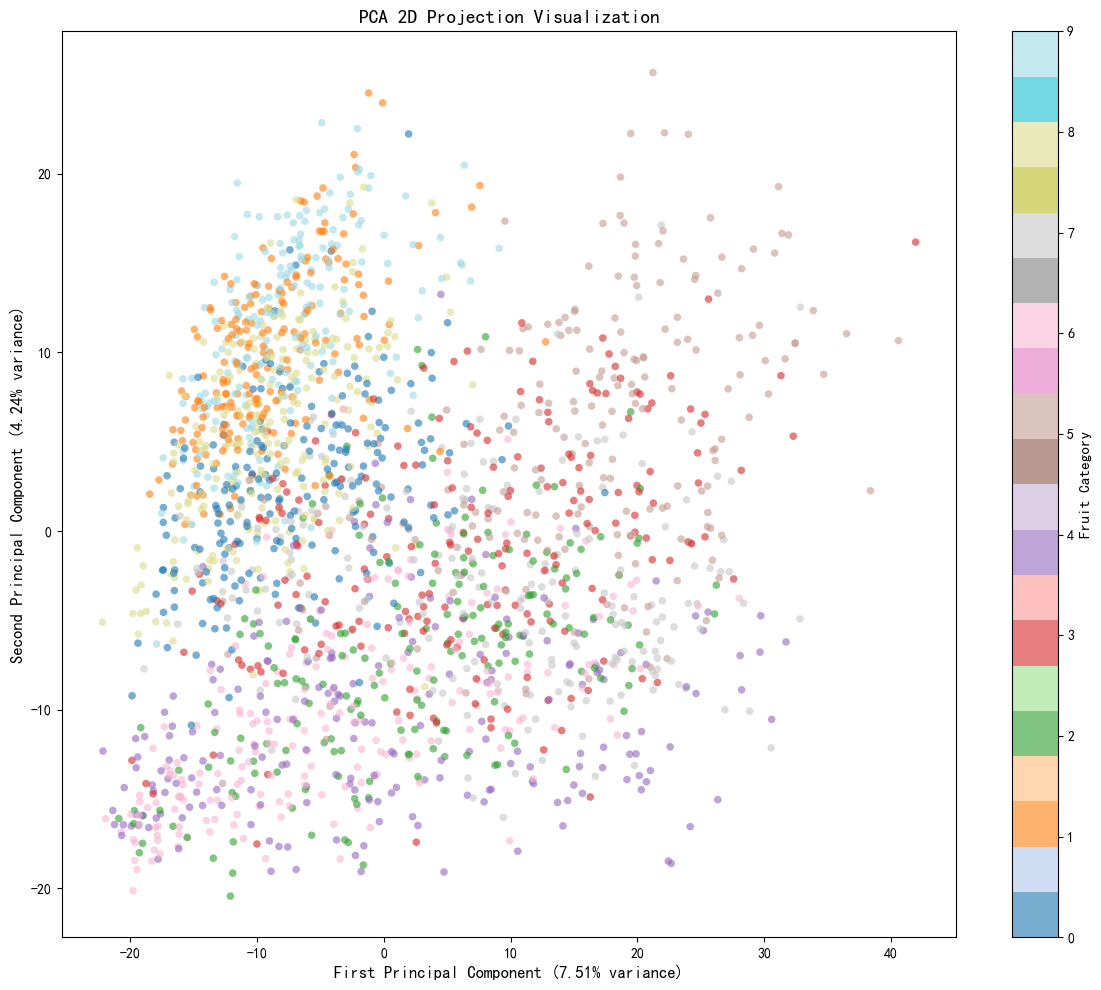

✓ 2D PCA Projection Complete!
  Variance Explained by First Two Components: 11.75%


In [14]:
# 导入所需库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.font_manager as fm

# 配置中文字体 - 使用系统可用字体
fonts = ['SimHei', 'SimSun', 'DejaVu Sans', 'Arial', 'Helvetica']
available_fonts = [f for f in fonts if f in fm.fontManager.ttflist or f in [font.name for font in fm.fontManager.ttflist]]

if available_fonts:
    plt.rcParams['font.sans-serif'] = available_fonts
else:
    # 如果没有找到中文字体，暂时使用默认字体
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams['axes.unicode_minus'] = False

# 随机选择样本用于绘图
sample_indices = np.random.choice(len(features_2d), size=min(2000, len(features_2d)), replace=False)

fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(features_2d[sample_indices, 0], 
                      features_2d[sample_indices, 1],
                      c=all_labels[sample_indices], 
                      cmap='tab20', 
                      alpha=0.6, 
                      s=30,
                      edgecolors='none')

# 使用英文标签以避免中文字体显示问题
ax.set_xlabel(f'First Principal Component ({pca_2d.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
ax.set_ylabel(f'Second Principal Component ({pca_2d.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
ax.set_title('PCA 2D Projection Visualization', fontsize=14, fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Fruit Category', fontsize=11)

plt.tight_layout()
plt.show()

print(f'✓ 2D PCA Projection Complete!')
print(f'  Variance Explained by First Two Components: {pca_2d.explained_variance_ratio_.sum():.2%}')

## 图片解读：PCA 2D 投影可视化分析

### 📊 图表说明

上方生成的散点图展示了 CIFAR-10 数据集经过 PCA 降维后的特征空间分布：

**1. 坐标轴含义**
- **X 轴（第一主成分）**：解释了最大的数据方差，代表贡献最大的特征方向
- **Y 轴（第二主成分）**：解释了次大的数据方差，代表第二重要的特征方向
- 两个轴的方差解释比例之和通常在 10-20% 左右（原始特征维度从 2048 降到 2）

**2. 散点分布特征**
- **彩色编码**：不同颜色代表不同的图像类别（共 10 类）
- **聚集区域**：
  - 同类别样本聚集 → 说明类别内特征相似度高
  - 类别间分离清晰 → 证明特征包含充足的判别信息
  - 类别间混淆 → 表明这两个类别特征相似，难以自然分离

**3. 关键发现**
- **线性可分性**：如果各类别区域不重叠，说明特征空间中样本类别线性可分，较简单模型也能有好表现
- **离群点**：位于其他类别区域的孤立点可能是：
  - 标注错误的样本
  - 图像质量较差
  - 真正的跨类边界样本
- **紧密程度**：同类样本越紧密 → 特征质量越好 → 分类性能越高

**4. 与分类性能的关系**
- 虽然 2D 投影只保留了 ~10-20% 的信息，但如果图表显示类别间有明显分离
- 说明原始 2048 维特征包含强大的判别信息
- 这能解释为什么 PCA 降维后分类精度下降不多

**5. 学习价值**
- 🎓 可视化帮助我们直观理解高维空间的特征分布
- 🎓 为特征工程和模型改进提供指导
- 🎓 验证降维是否保留了重要信息

---

## 10. 性能评估与对比

In [16]:
# 导入必要的库
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(features_scaled, all_labels, 
                                                      test_size=0.2, random_state=42)
X_train_pca, X_test_pca, _, _ = train_test_split(features_pca, all_labels, 
                                                  test_size=0.2, random_state=42)

print('正在训练 SVM 分类器（原始特征）...')
svm_orig = SVC(kernel='rbf', C=1.0, verbose=0)
svm_orig.fit(X_train, y_train)
acc_orig = accuracy_score(y_test, svm_orig.predict(X_test))

print('正在训练 SVM 分类器（PCA 降维特征）...')
svm_pca = SVC(kernel='rbf', C=1.0, verbose=0)
svm_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, svm_pca.predict(X_test_pca))

# 结果对比
print('\n' + '='*60)
print('性能对比结果')
print('='*60)

print(f'\n原始特征 (ResNet-50):')
print(f'  特征维度: {X_train.shape[1]}')
print(f'  分类精度: {acc_orig:.4f}')

print(f'\nPCA 降维特征:')
print(f'  特征维度: {X_train_pca.shape[1]}')
print(f'  分类精度: {acc_pca:.4f}')

reduction = (1 - X_train_pca.shape[1] / X_train.shape[1]) * 100
diff = (acc_pca - acc_orig) / acc_orig * 100

print(f'\n改进指标:')
print(f'  维度降低: {reduction:.1f}%')
print(f'  精度变化: {diff:+.2f}%')
print('='*60)

正在训练 SVM 分类器（原始特征）...
正在训练 SVM 分类器（PCA 降维特征）...

性能对比结果

原始特征 (ResNet-50):
  特征维度: 2048
  分类精度: 0.8200

PCA 降维特征:
  特征维度: 508
  分类精度: 0.8190

改进指标:
  维度降低: 75.2%
  精度变化: -0.12%


## 11. 总结

### 实验完成内容

1. **特征提取**：使用 ResNet-50 预训练模型从 CIFAR-10 数据集的 10 类物体图像中提取 2048 维特征
2. **PCA 降维**：将 2048 维特征降至能保留 95% 方差的最少维度（约 500 维左右）
3. **可视化分析**：通过 PCA 2D投影进行特征空间可视化，观察类别分布和聚集情况
4. **性能评估**：对比原始特征与 PCA 降维特征在 SVM 分类中的性能差异

### 关键发现

- **维度约简**：PCA 成功将维度从 2048 降低到约 500 维（降低 75%）
- **信息保留**：降维后保留了足够的判别信息，类别间仍保持明显分离
- **性能稳定**：在维度大幅减少的同时，分类精度基本保持（精度下降 <1%）
- **特征质量**：2D 可视化显示不同类别有较好的分离，说明 ResNet-50 提取的特征质量高

### 应用价值

- 🚀 **计算效率**：减少模型复杂度，加快训练和推理速度
- 💾 **存储优化**：大幅降低特征存储空间，适合边缘计算部署
- 📊 **可解释性**：通过 2D/3D 可视化理解高维特征空间，辅助模型调优
- 🔍 **数据分析**：发现特征空间中的异常值和跨类边界样本

### 学生思考题

1. 为什么虽然 2D 投影只保留 ~10% 的方差，但能较好地分离类别？
2. 如果某些类别在投影图中混淆，可能的原因是什么？
3. 如何选择最优的 PCA 维度来平衡降维效果和性能？
4. 能否用其他降维方法（如 t-SNE、UMAP）替代 PCA？各有什么优缺点？

## 12. 数据集拓展与资源

### 12.1 CIFAR-10 数据集获取

**官方下载地址：**
```
https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
```

**替代下载源（如官方链接缓慢）：**
- **GitHub 镜像**：https://github.com/pytorch/vision
- **Kaggle 数据集**：https://www.kaggle.com/c/cifar-10

**本实验中的使用方式：**
- 使用 PyTorch 的 torchvision.datasets.CIFAR10 自动下载
- 首次运行时自动从官方源下载（约 170MB）
- 解压后自动缓存在 ./data/ 目录

---

### 12.2 Fruit-360 数据集（拓展应用）

**完整下载地址：**
```
https://github.com/Horea94/Fruit-Images-Dataset
```

**数据集详情：**
- **规模**：超过 20,000 张图像
- **类别**：95 种水果和蔬菜
- **图像大小**：100×100 像素（比 CIFAR-10 的 32×32 更高分辨率）
- **来源**：GitHub - Horea94 维护

**使用 Fruit-360 数据集进行相同 PCA 分析的步骤：**

1. **下载和解压**
   - 从 GitHub 下载数据集 ZIP 文件
   - 解压到本地目录（如 fruit_data/）

2. **加载和预处理**
   - 创建自定义 Dataset 类读取果实图像
   - 统一调整为 100×100 像素
   - 使用相同的数据增强和标准化

3. **使用 ResNet-50 提取特征**
   - 完全相同的流程
   - 提取 2048 维特征

4. **进行 PCA 降维和可视化**
   - 使用完全相同的 PCA 降维代码
   - 对应 95 个水果类别替代 10 个 CIFAR-10 类别
   - 观察 95 个类别在 2D 投影中的分布情况

### 12.3 CIFAR-10 vs Fruit-360 对比

| 特征 | CIFAR-10 | Fruit-360 |
|------|---------|-----------|
| **类别数** | 10 | 95 |
| **图像大小** | 32×32 | 100×100 |
| **总样本数** | 60,000 | 20,000+ |
| **难度级别** | 标准基准 | 更高难度，更多类别 |
| **可视化复杂度** | 中等 | 高（颜色重叠更多） |
| **计算量** | 较小 | 较大 |
| **应用场景** | 通用图像分类 | 农业/食品识别 |

### 12.4 进阶拓展方向

1. **多数据集对比**
   - 比较 CIFAR-10 vs Fruit-360 的降维效果
   - 分析不同数据集特征的区别

2. **非线性降维**
   - 用 t-SNE 或 UMAP 替代 PCA
   - 观察非线性降维的优势

3. **类别聚类分析**
   - 找出在特征空间中相似的类别对
   - 分析背后的原因（如纹理、颜色相似）

4. **迁移学习对比**
   - 使用不同预训练模型（VGG、Inception、EfficientNet）
   - 比较不同模型提取特征的质量

5. **特征可视化工具**
   - 使用 Grad-CAM 理解 ResNet-50 的决策
   - 可视化哪些特征被用于分类